# 02 — Analyse exploratoire des données (EDA)

**Objectif** : Explorer et visualiser le jeu de données Oscar + IMDb afin de mieux comprendre sa structure, ses distributions, et de formuler des hypothèses pour la modélisation.

**Dataset principal** : `Data/Processed/oscar_imdb_merged.csv`  
**Période couverte** : Cérémonies 2000–2022  
**Auteurs** : Anna, Keira, Robin, Jonathan


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
PALETTE_WIN = {True: '#F4A261', False: '#457B9D'}  # orange = gagnant, bleu = nommé

# Chemins
ROOT = Path('..').resolve()
DATA_MERGED = ROOT / 'Data' / 'Processed' / 'oscar_imdb_merged.csv'
DATA_RAW_OSCAR = ROOT / 'Data' / 'Raw' / 'Scraping' / 'all_data_oscars.csv'

print(f'Répertoire racine : {ROOT}')
print(f'Fichier merged    : {DATA_MERGED.exists()}')
print(f'Fichier oscar raw : {DATA_RAW_OSCAR.exists()}')

Répertoire racine : /Users/jo/Desktop/applied_ml_for_business
Fichier merged    : True
Fichier oscar raw : True


## 1. Chargement & Aperçu des Données

In [2]:
df = pd.read_csv(DATA_MERGED)

# Nettoyage minimal
df['winner'] = df['winner'].astype(bool)

print(f'Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Période : {df["year"].min()} → {df["year"].max()}')
print(f'Cérémonies : {df["ceremony_number"].nunique()}')
print(f'Films uniques : {df["tconst"].nunique()}')
print(f'Catégories : {df["category"].nunique()}')
print(f'Gagnants : {df["winner"].sum()} ({df["winner"].mean()*100:.1f}%)')
df.head()

Shape : 2427 lignes × 30 colonnes
Période : 2000 → 2026
Cérémonies : 27
Films uniques : 1097
Catégories : 23
Gagnants : 490 (20.2%)


,tconst,nconst,tmdb_id,year,ceremony_number,category,nominee,nominee_type,winner,film_title,...,overview,tagline,release_date,original_language,keywords,production_countries,budget,revenue,tmdb_vote_average,tmdb_vote_count
0,tt0169547,NaN,14.0,2000,72,Best Picture,American Beauty,film,True,American Beauty,...,"Lester Burnham, a depressed suburban father in...",... look closer,1999-09-15,en,['estate agent' 'adultery' 'coming out' 'first...,['US'],15000000.0,356296601.0,8.001,13009.0
1,tt0124315,NaN,1715.0,2000,72,Best Picture,The Cider House Rules,film,False,The Cider House Rules,...,"Homer is an orphan who was never adopted, beco...",A story about how far we must travel to find t...,1999-12-17,en,['based on novel or book' 'orphanage' 'pregnan...,['US'],24000000.0,88500000.0,7.087,1286.0
2,tt0120689,NaN,497.0,2000,72,Best Picture,The Green Mile,film,False,The Green Mile,...,A supernatural tale set on death row in a Sout...,Paul Edgecomb didn't believe in miracles. Unti...,1999-12-10,en,['mentally disabled' 'death penalty' 'based on...,['US'],60000000.0,286801374.0,8.505,19209.0
3,tt0140352,NaN,9008.0,2000,72,Best Picture,The Insider,film,False,The Insider,...,A research chemist comes under personal and pr...,Two men driven to tell the truth … whatever th...,1999-10-28,en,['newspaper' 'research' 'politics' 'spy' 'jour...,['US'],90000000.0,60300000.0,7.460,2060.0
4,tt0167404,NaN,745.0,2000,72,Best Picture,The Sixth Sense,film,False,The Sixth Sense,...,"Following an unexpected tragedy, child psychol...",Not every gift is a blessing.,1999-08-06,en,['dying and death' 'child abuse' 'philadelphia...,['US'],40000000.0,672800000.0,7.951,12817.0


In [3]:
# Résumé statistique des variables numériques
df[['imdb_rating', 'imdb_votes', 'runtime_minutes', 'n_genres', 'n_cast']].describe().round(2)

,imdb_rating,imdb_votes,runtime_minutes,n_genres,n_cast
count,2414.00,2414.00,2417.00,2427.00,2329.00
mean,7.40,412633.99,125.43,2.59,10.05
std,0.72,481496.28,26.24,0.66,1.51
min,3.20,6.00,49.00,0.00,1.00
25%,7.10,102550.00,107.00,2.00,10.00
50%,7.50,255018.00,122.00,3.00,10.00
75%,7.80,547381.00,139.00,3.00,10.00
max,9.10,3155324.00,467.00,3.00,22.00


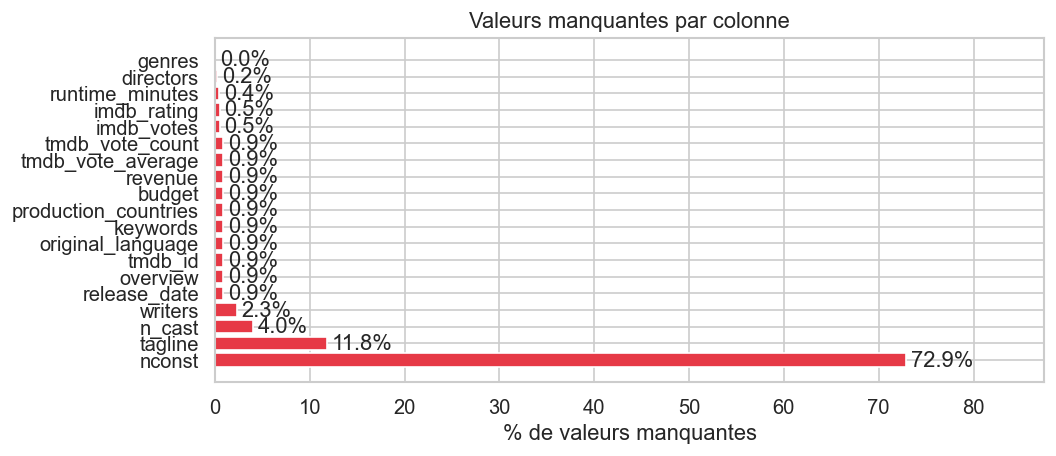

In [4]:
# Valeurs manquantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(missing.index, pct.values, color='#E63946')
ax.bar_label(bars, labels=[f'{v}%' for v in pct.values], padding=3)
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne')
ax.set_xlim(0, pct.max() * 1.2)
plt.tight_layout()
plt.show()

## 2. Distribution des Nominations dans le Temps

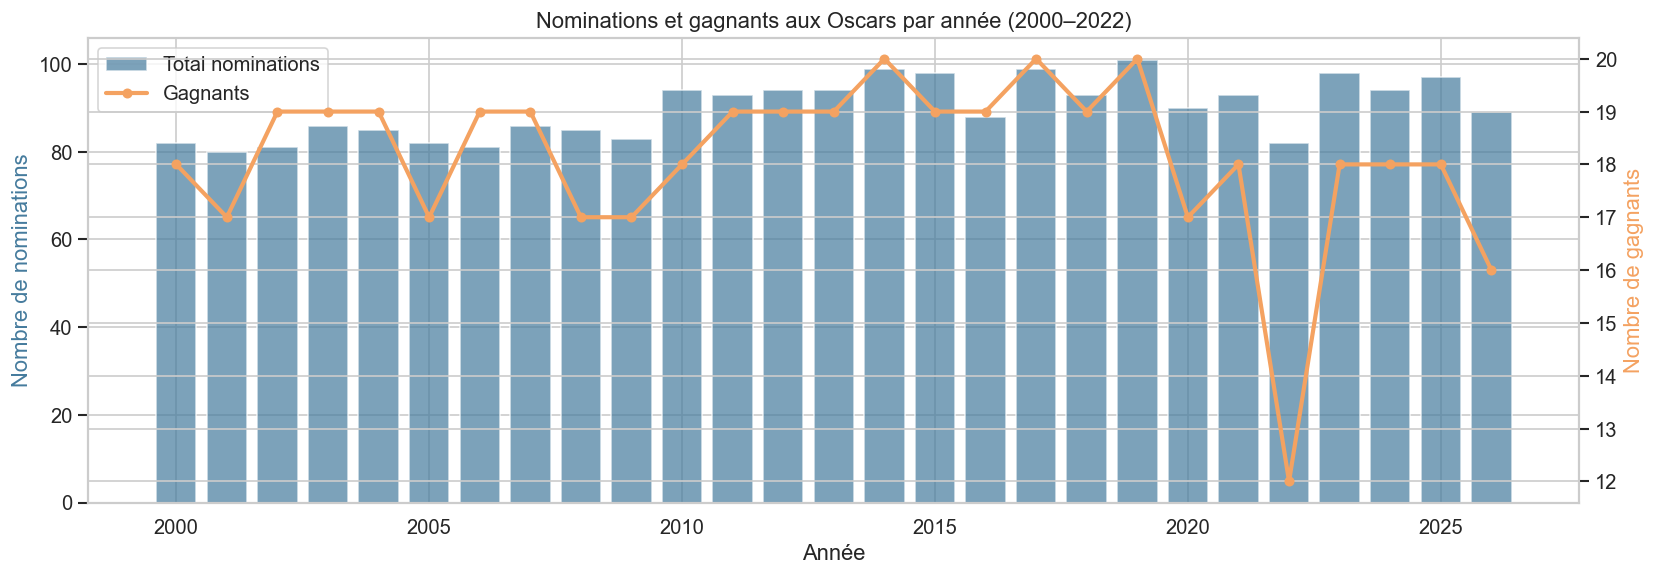

In [5]:
# Nominations et gagnants par année
yearly = df.groupby('year').agg(
    total_nominations=('winner', 'count'),
    winners=('winner', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(yearly['year'], yearly['total_nominations'], color='#457B9D', alpha=0.7, label='Total nominations')
ax2.plot(yearly['year'], yearly['winners'], color='#F4A261', lw=2.5, marker='o', ms=5, label='Gagnants')

ax1.set_xlabel('Année')
ax1.set_ylabel('Nombre de nominations', color='#457B9D')
ax2.set_ylabel('Nombre de gagnants', color='#F4A261')
ax1.set_title('Nominations et gagnants aux Oscars par année (2000–2022)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

## 3. Analyse par Catégorie

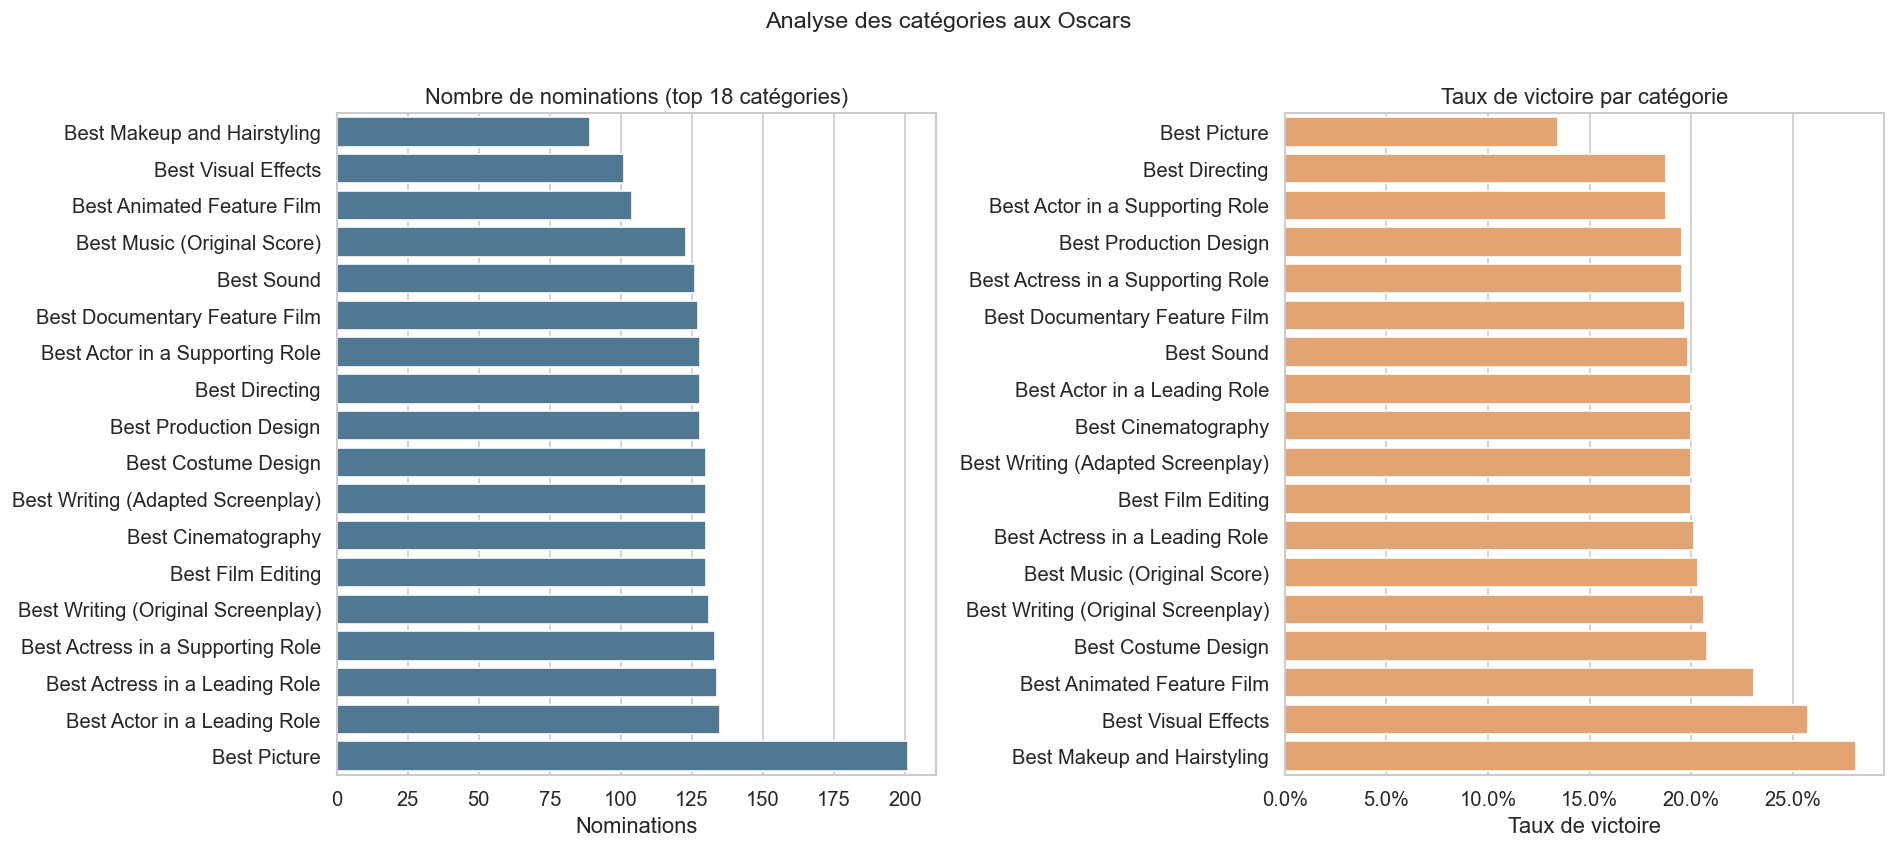

In [6]:
# Top catégories par nombre de nominations
cat_stats = df.groupby('category').agg(
    nominations=('winner', 'count'),
    winners=('winner', 'sum')
).reset_index()
cat_stats['win_rate'] = cat_stats['winners'] / cat_stats['nominations']
cat_stats = cat_stats.sort_values('nominations', ascending=False).head(18)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Nombre de nominations
sns.barplot(data=cat_stats.sort_values('nominations', ascending=True),
            x='nominations', y='category', color='#457B9D', ax=axes[0])
axes[0].set_title('Nombre de nominations (top 18 catégories)')
axes[0].set_xlabel('Nominations')
axes[0].set_ylabel('')

# Taux de victoire (= 1/nb_nommés en théorie)
sns.barplot(data=cat_stats.sort_values('win_rate', ascending=True),
            x='win_rate', y='category', color='#F4A261', ax=axes[1])
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title('Taux de victoire par catégorie')
axes[1].set_xlabel('Taux de victoire')
axes[1].set_ylabel('')

plt.suptitle('Analyse des catégories aux Oscars', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Note IMDb : Nommés vs Gagnants

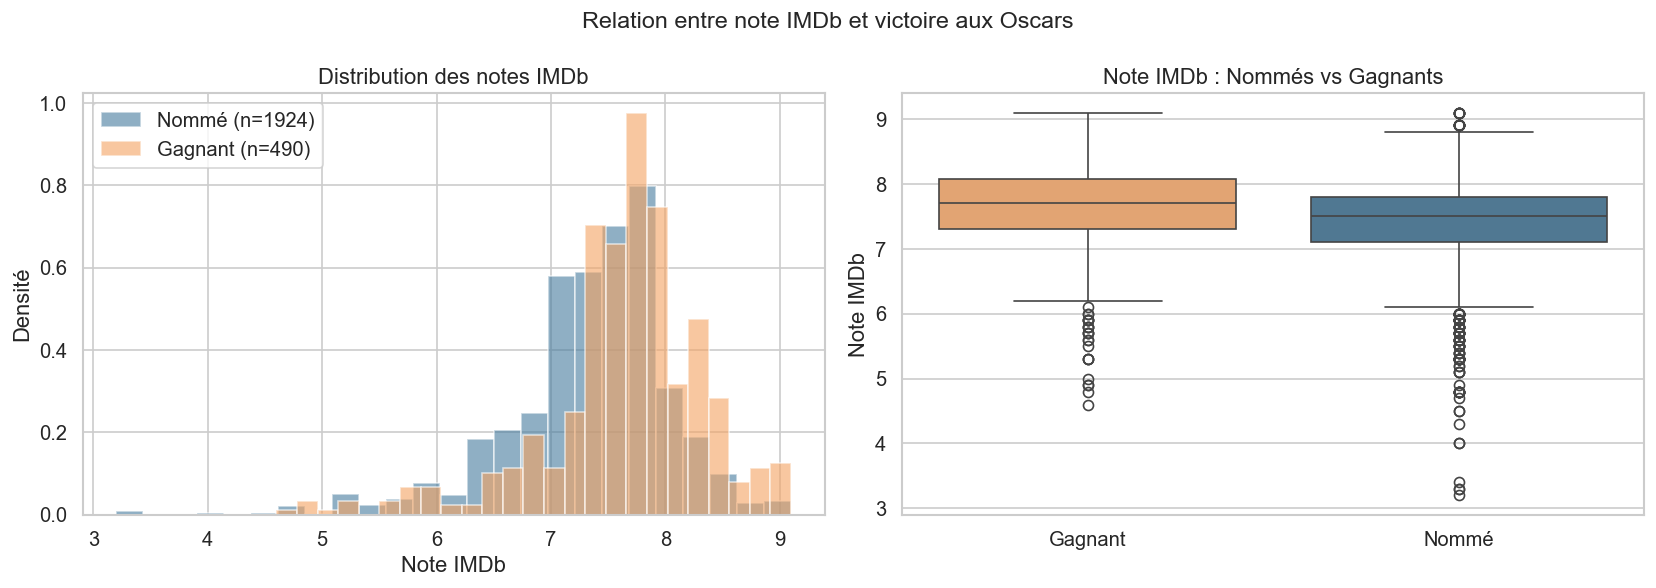

Note IMDb moyenne — Nommés  : 7.347
Note IMDb moyenne — Gagnants: 7.625


In [7]:
# Distribution des notes IMDb selon le statut gagnant/nommé
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
for win, label in [(False, 'Nommé'), (True, 'Gagnant')]:
    subset = df[df['winner'] == win]['imdb_rating'].dropna()
    axes[0].hist(subset, bins=25, alpha=0.6,
                 color=PALETTE_WIN[win], label=f'{label} (n={len(subset)})', density=True)
axes[0].set_xlabel('Note IMDb')
axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution des notes IMDb')
axes[0].legend()

# Boxplot
df_plot = df[['imdb_rating', 'winner']].dropna()
df_plot['Statut'] = df_plot['winner'].map({True: 'Gagnant', False: 'Nommé'})
sns.boxplot(data=df_plot, x='Statut', y='imdb_rating',
            palette={'Gagnant': '#F4A261', 'Nommé': '#457B9D'}, ax=axes[1])
axes[1].set_title('Note IMDb : Nommés vs Gagnants')
axes[1].set_ylabel('Note IMDb')
axes[1].set_xlabel('')

plt.suptitle('Relation entre note IMDb et victoire aux Oscars', fontsize=14)
plt.tight_layout()
plt.show()

# Moyennes
print('Note IMDb moyenne — Nommés  :', round(df[df['winner']==False]['imdb_rating'].mean(), 3))
print('Note IMDb moyenne — Gagnants:', round(df[df['winner']==True]['imdb_rating'].mean(), 3))

## 5. Popularité (Votes IMDb)

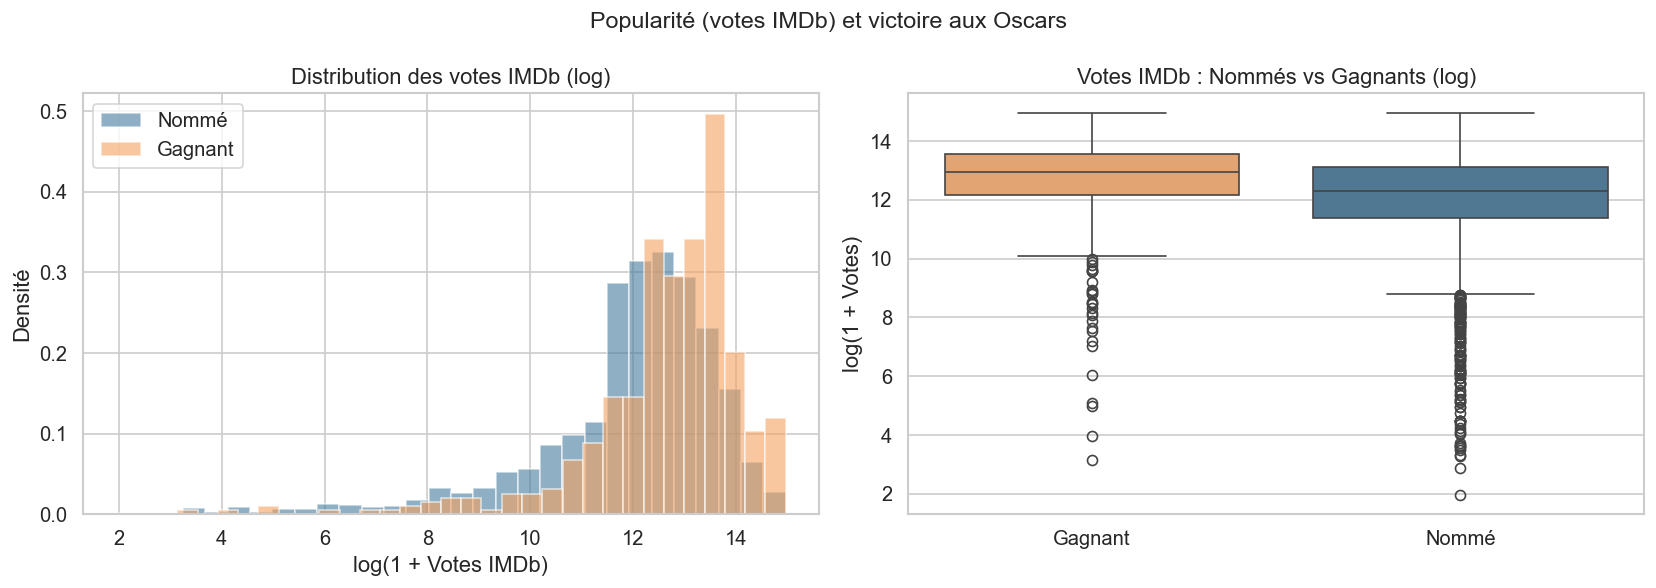

In [8]:
# Distribution du nombre de votes (log-scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for win, label in [(False, 'Nommé'), (True, 'Gagnant')]:
    subset = df[df['winner'] == win]['imdb_votes'].dropna()
    axes[0].hist(np.log1p(subset), bins=30, alpha=0.6,
                 color=PALETTE_WIN[win], label=f'{label}', density=True)
axes[0].set_xlabel('log(1 + Votes IMDb)')
axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution des votes IMDb (log)')
axes[0].legend()

df_plot2 = df[['imdb_votes', 'winner']].dropna()
df_plot2['Statut'] = df_plot2['winner'].map({True: 'Gagnant', False: 'Nommé'})
df_plot2['log_votes'] = np.log1p(df_plot2['imdb_votes'])
sns.boxplot(data=df_plot2, x='Statut', y='log_votes',
            palette={'Gagnant': '#F4A261', 'Nommé': '#457B9D'}, ax=axes[1])
axes[1].set_title('Votes IMDb : Nommés vs Gagnants (log)')
axes[1].set_ylabel('log(1 + Votes)')
axes[1].set_xlabel('')

plt.suptitle('Popularité (votes IMDb) et victoire aux Oscars', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Analyse des Genres

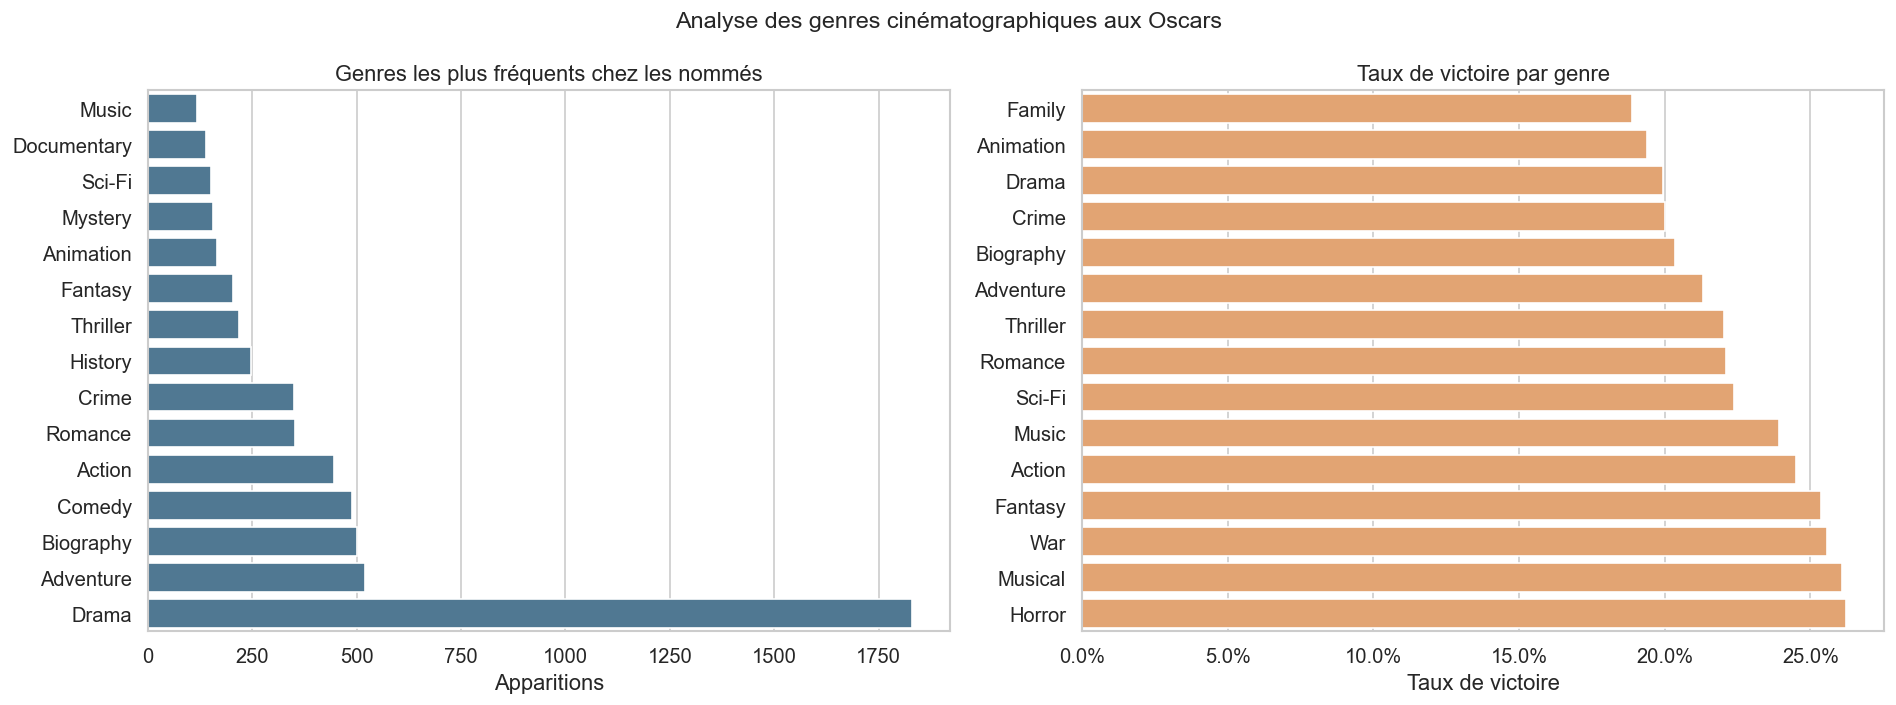

In [9]:
# Exploser les genres (un film peut avoir plusieurs genres)
df_genres = df.dropna(subset=['genres']).copy()
df_genres['genre_list'] = df_genres['genres'].str.split(',')
df_exploded = df_genres.explode('genre_list')
df_exploded['genre_list'] = df_exploded['genre_list'].str.strip()

genre_stats = df_exploded.groupby('genre_list').agg(
    count=('winner', 'count'),
    win_rate=('winner', 'mean')
).reset_index()
genre_stats = genre_stats[genre_stats['count'] >= 10].sort_values('count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fréquence des genres parmi les nommés
top_genres = genre_stats.sort_values('count', ascending=True).tail(15)
sns.barplot(data=top_genres, x='count', y='genre_list', color='#457B9D', ax=axes[0])
axes[0].set_title('Genres les plus fréquents chez les nommés')
axes[0].set_xlabel('Apparitions')
axes[0].set_ylabel('')

# Taux de victoire par genre
top_winrate = genre_stats.sort_values('win_rate', ascending=True).tail(15)
sns.barplot(data=top_winrate, x='win_rate', y='genre_list', color='#F4A261', ax=axes[1])
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title('Taux de victoire par genre')
axes[1].set_xlabel('Taux de victoire')
axes[1].set_ylabel('')

plt.suptitle('Analyse des genres cinématographiques aux Oscars', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Durée des Films (Runtime)

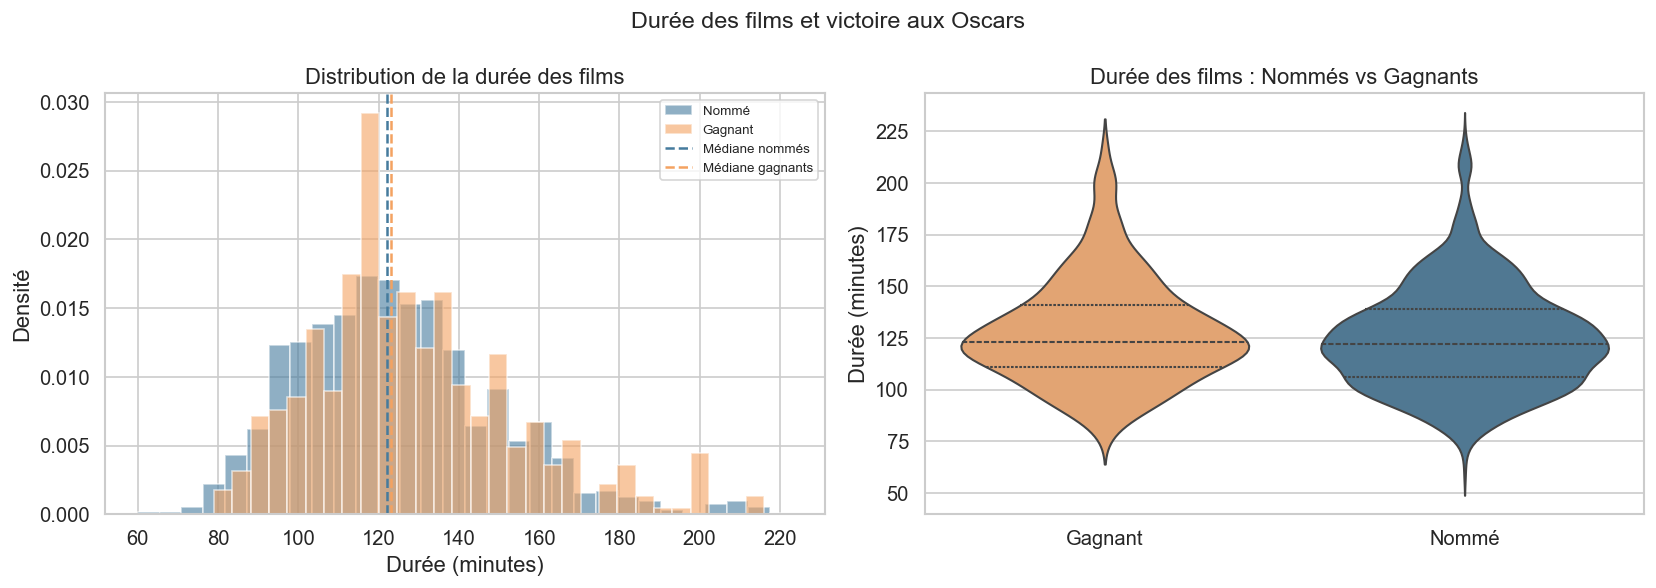

Durée médiane — Nommés  : 122.0 min
Durée médiane — Gagnants: 123.0 min


In [10]:
# Filtrer les durées aberrantes
df_rt = df[(df['runtime_minutes'] >= 60) & (df['runtime_minutes'] <= 240)].copy()
df_rt['Statut'] = df_rt['winner'].map({True: 'Gagnant', False: 'Nommé'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
for win, label in [(False, 'Nommé'), (True, 'Gagnant')]:
    subset = df_rt[df_rt['winner'] == win]['runtime_minutes']
    axes[0].hist(subset, bins=30, alpha=0.6, color=PALETTE_WIN[win], label=label, density=True)
axes[0].axvline(df_rt[df_rt['winner']==False]['runtime_minutes'].median(),
                color='#457B9D', ls='--', lw=1.5, label='Médiane nommés')
axes[0].axvline(df_rt[df_rt['winner']==True]['runtime_minutes'].median(),
                color='#F4A261', ls='--', lw=1.5, label='Médiane gagnants')
axes[0].set_xlabel('Durée (minutes)')
axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution de la durée des films')
axes[0].legend(fontsize=8)

# Violin plot
sns.violinplot(data=df_rt, x='Statut', y='runtime_minutes',
               palette={'Gagnant': '#F4A261', 'Nommé': '#457B9D'}, ax=axes[1], inner='quartile')
axes[1].set_title('Durée des films : Nommés vs Gagnants')
axes[1].set_ylabel('Durée (minutes)')
axes[1].set_xlabel('')

plt.suptitle('Durée des films et victoire aux Oscars', fontsize=14)
plt.tight_layout()
plt.show()

print('Durée médiane — Nommés  :', df_rt[df_rt['winner']==False]['runtime_minutes'].median(), 'min')
print('Durée médiane — Gagnants:', df_rt[df_rt['winner']==True]['runtime_minutes'].median(), 'min')

## 8. Matrice de Corrélation des Variables Numériques

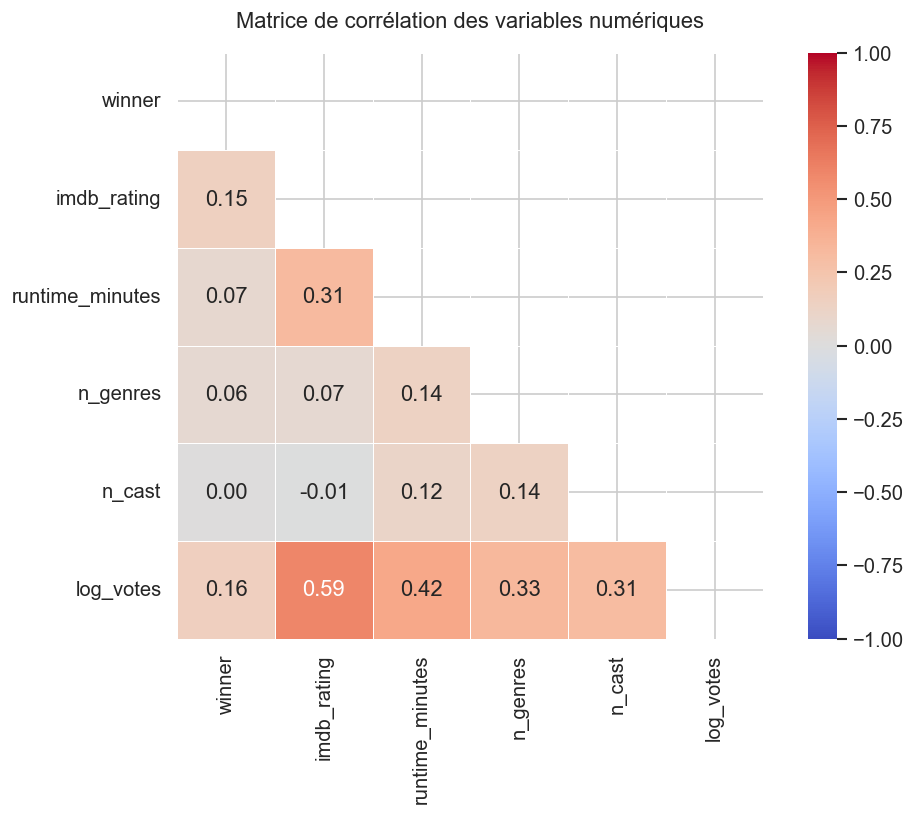

In [11]:
# Sélection des features numériques
num_cols = ['winner', 'imdb_rating', 'imdb_votes', 'runtime_minutes', 'n_genres', 'n_cast']
df_corr = df[num_cols].copy()
df_corr['winner'] = df_corr['winner'].astype(int)
df_corr['log_votes'] = np.log1p(df_corr['imdb_votes'])
df_corr = df_corr.drop(columns='imdb_votes')  # remplacé par log_votes

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=.5, ax=ax)
ax.set_title('Matrice de corrélation des variables numériques', pad=15)
plt.tight_layout()
plt.show()

## 9. Évolution de la Note IMDb dans le Temps

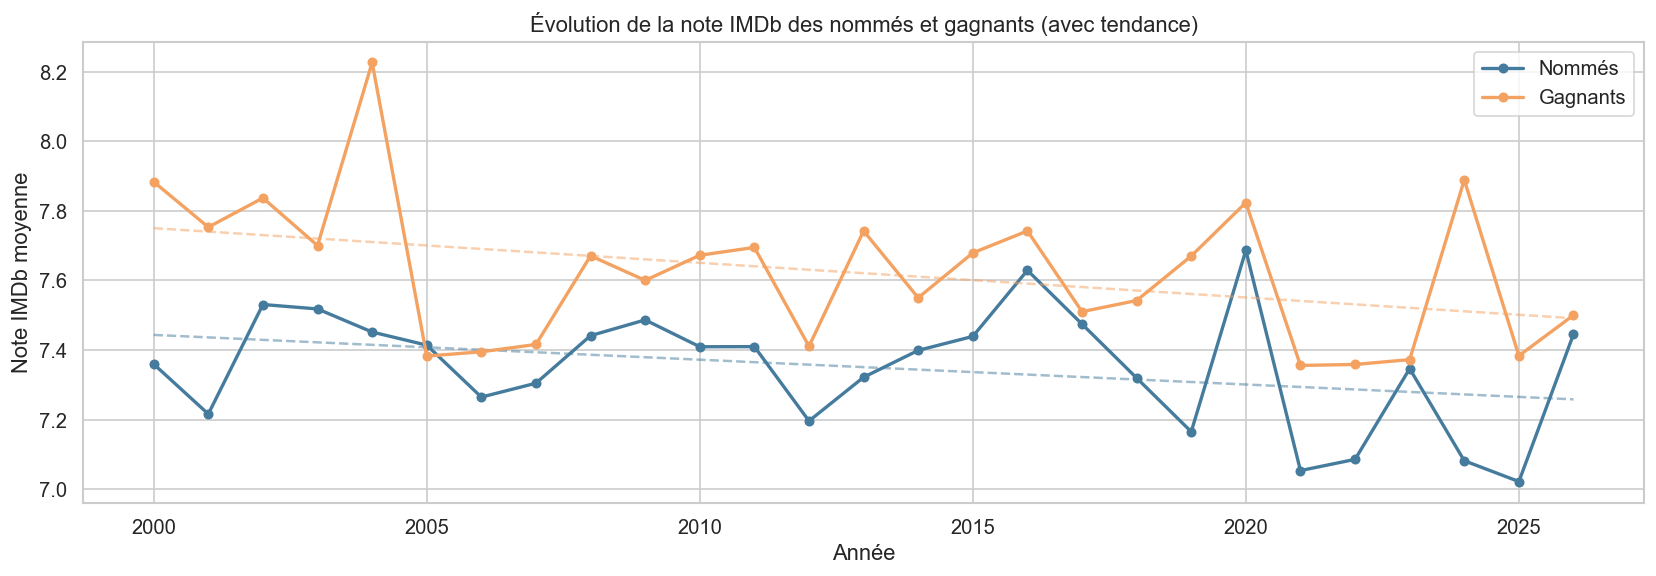

In [12]:
# Note IMDb moyenne des nommés et gagnants par année
rating_yearly = df.groupby(['year', 'winner'])['imdb_rating'].mean().reset_index()
rating_yearly['Statut'] = rating_yearly['winner'].map({True: 'Gagnant', False: 'Nommé'})

fig, ax = plt.subplots(figsize=(14, 5))
for win, label, color in [(False, 'Nommés', '#457B9D'), (True, 'Gagnants', '#F4A261')]:
    subset = rating_yearly[rating_yearly['winner'] == win]
    ax.plot(subset['year'], subset['imdb_rating'], marker='o', ms=5,
            color=color, lw=2, label=label)
    # Tendance
    z = np.polyfit(subset['year'], subset['imdb_rating'], 1)
    p = np.poly1d(z)
    ax.plot(subset['year'], p(subset['year']), ls='--', color=color, alpha=0.5, lw=1.5)

ax.set_xlabel('Année')
ax.set_ylabel('Note IMDb moyenne')
ax.set_title('Évolution de la note IMDb des nommés et gagnants (avec tendance)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Focus : Best Picture

Best Picture — 201 entrées, 27 gagnants
Note IMDb moyenne des gagnants Best Picture : nan


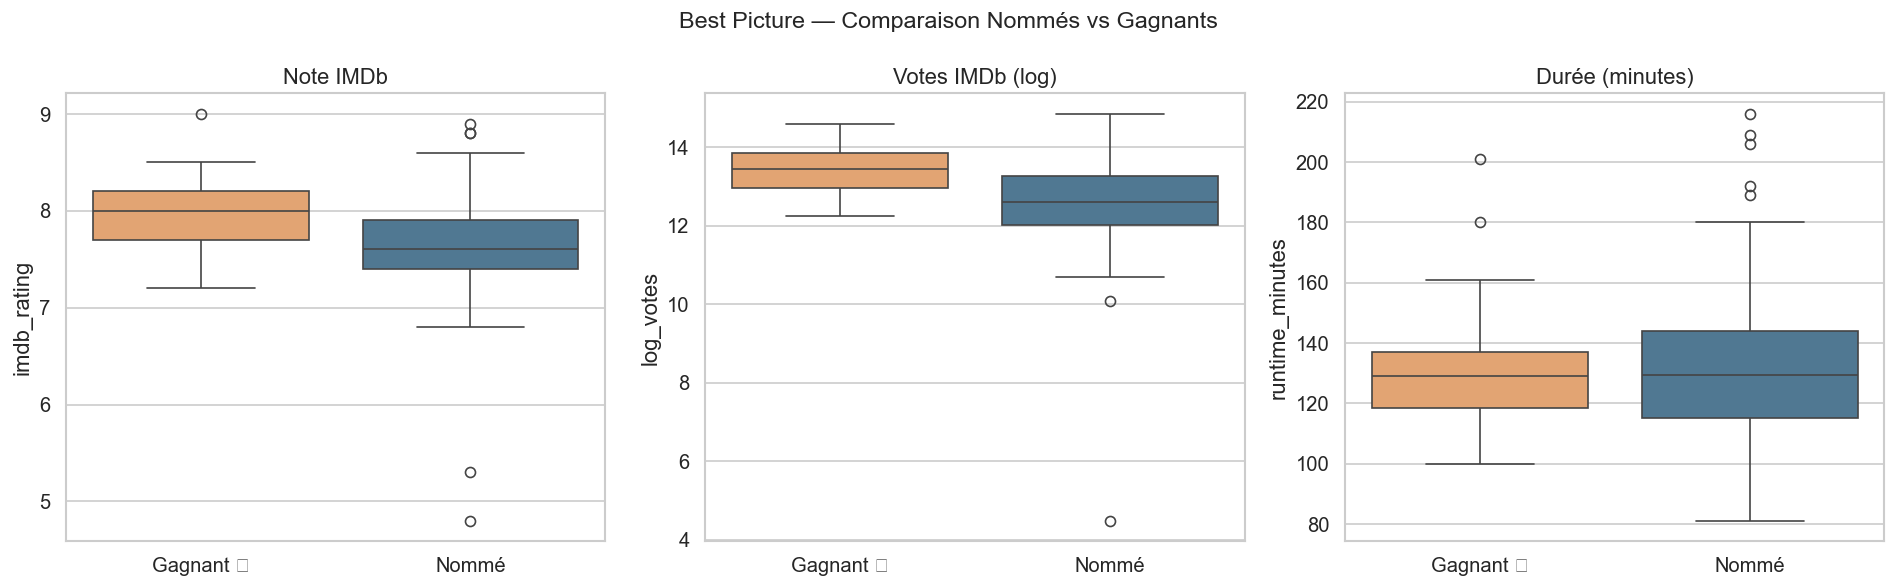

In [13]:
# Zoom sur la catégorie phare
bp = df[df['category'] == 'Best Picture'].copy()
bp['Statut'] = bp['winner'].map({True: 'Gagnant ✓', False: 'Nommé'})

print(f'Best Picture — {len(bp)} entrées, {bp["winner"].sum()} gagnants')
print(f'Note IMDb moyenne des gagnants Best Picture : {bp[bp["winner"]=="True"]["imdb_rating"].mean():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Note IMDb
sns.boxplot(data=bp, x='Statut', y='imdb_rating',
            palette={'Gagnant ✓': '#F4A261', 'Nommé': '#457B9D'}, ax=axes[0])
axes[0].set_title('Note IMDb')
axes[0].set_xlabel('')

# Votes
bp['log_votes'] = np.log1p(bp['imdb_votes'])
sns.boxplot(data=bp, x='Statut', y='log_votes',
            palette={'Gagnant ✓': '#F4A261', 'Nommé': '#457B9D'}, ax=axes[1])
axes[1].set_title('Votes IMDb (log)')
axes[1].set_xlabel('')

# Durée
bp_rt = bp[(bp['runtime_minutes'] >= 60) & (bp['runtime_minutes'] <= 240)]
sns.boxplot(data=bp_rt, x='Statut', y='runtime_minutes',
            palette={'Gagnant ✓': '#F4A261', 'Nommé': '#457B9D'}, ax=axes[2])
axes[2].set_title('Durée (minutes)')
axes[2].set_xlabel('')

plt.suptitle('Best Picture — Comparaison Nommés vs Gagnants', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Analyse de Genre — Représentation et impact sur les modèles

**Question** : Quelle est la proportion de femmes parmi les nominé·e·s et gagnant·e·s ? Cela influence-t-il les signaux que verront nos modèles ML ?

**Sources de genre** :
- **Catégories d'acting** : le genre est *structurellement* encodé dans le nom de la catégorie (`Best Actor*` → M, `Best Actress*` → F). C'est une variable binaire propre, sans inférence.
- **Meilleur Réalisateur** : 90 réalisateur·rice·s unique·s sur la période — set curé manuellement des 8 femmes nominées (Bigelow, Coppola, Campion, Gerwig, Zhao, Fennell, Triet, Fargeat).
- **Autres catégories "film"** (Best Picture, VFX, Animation, Screenplay) : pas d'imputation — l'unité d'analyse est le film, pas une personne unique.

**Pourquoi c'est important pour le ML** : si une catégorie est structurellement déséquilibrée (ex : 93 % de réalisateurs masculins), le modèle ne peut pas "apprendre" un effet de genre fiable, et `class_weight` ou `is_overdue` peuvent masquer un biais historique. À identifier avant d'interpréter les coefficients.

In [14]:
# Set curé manuellement (revérifié sur la liste des 90 réalisateur·rice·s unique·s — cf. §3)
FEMALE_DIRECTORS = {
    'Chloé Zhao', 'Coralie Fargeat', 'Emerald Fennell', 'Greta Gerwig',
    'Jane Campion', 'Justine Triet', 'Kathryn Bigelow', 'Sofia Coppola',
}

ACTING_CATS = {
    'Best Actor in a Leading Role':      'M',
    'Best Actor in a Supporting Role':   'M',
    'Best Actress in a Leading Role':    'F',
    'Best Actress in a Supporting Role': 'F',
}

df_gender = df.copy()
df_gender['gender'] = np.where(
    df_gender['category'].isin(ACTING_CATS),
    df_gender['category'].map(ACTING_CATS),
    np.where(
        (df_gender['category'] == 'Best Directing') & df_gender['nominee'].isin(FEMALE_DIRECTORS), 'F',
        np.where(df_gender['category'] == 'Best Directing', 'M', None)
    )
)
df_gender_p = df_gender.dropna(subset=['gender']).copy()

print(f'Lignes avec genre identifié : {len(df_gender_p)} / {len(df)} ({len(df_gender_p)/len(df)*100:.1f} %)')
print(f'Décomposition par catégorie :')
print(df_gender_p.groupby(['category', 'gender']).size().unstack(fill_value=0))

Lignes avec genre identifié : 658 / 2427 (27.1 %)
Décomposition par catégorie :
gender                               F    M
category                                   
Best Actor in a Leading Role         0  135
Best Actor in a Supporting Role      0  128
Best Actress in a Leading Role     134    0
Best Actress in a Supporting Role  133    0
Best Directing                       9  119


### 11.1 Proportion globale dans les catégories "personne"

Vue d'ensemble : combien d'hommes vs femmes parmi les nominé·e·s, et parmi les gagnant·e·s ?

        nominations  wins  win_rate  share_of_noms  share_of_wins
gender                                                           
F               276    56     0.203          0.419          0.438
M               382    72     0.188          0.581          0.562


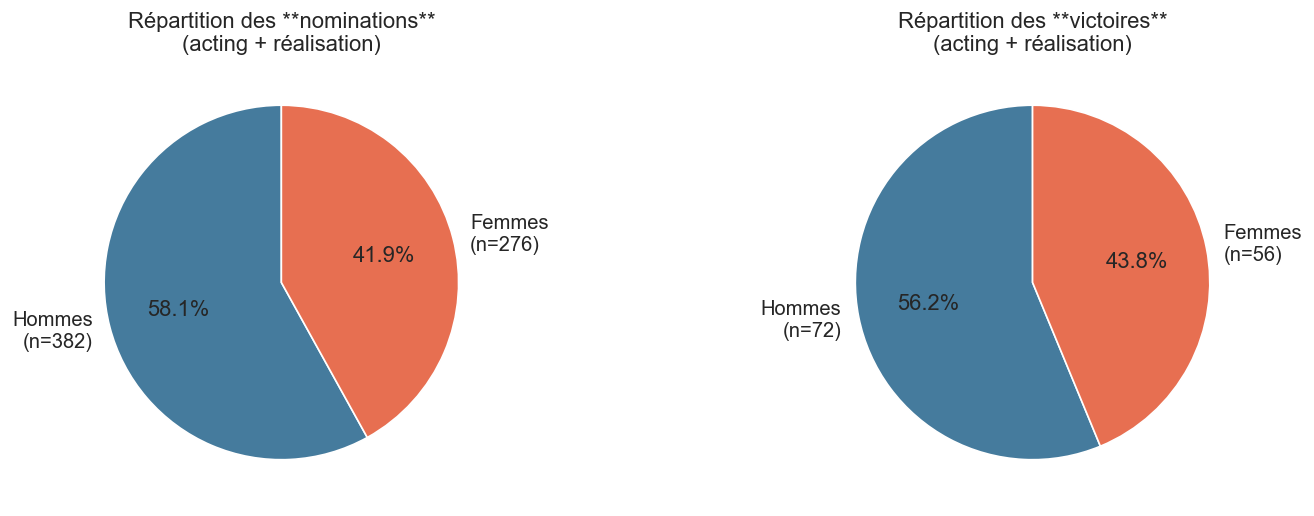

In [15]:
# Comptages globaux (acting + directing)
summary = df_gender_p.groupby('gender').agg(
    nominations=('winner', 'count'),
    wins=('winner', 'sum'),
)
summary['win_rate'] = summary['wins'] / summary['nominations']
summary['share_of_noms'] = summary['nominations'] / summary['nominations'].sum()
summary['share_of_wins'] = summary['wins'] / summary['wins'].sum()
print(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = ['Hommes', 'Femmes']
colors = ['#457B9D', '#E76F51']

noms = [summary.loc['M', 'nominations'], summary.loc['F', 'nominations']]
wins = [summary.loc['M', 'wins'], summary.loc['F', 'wins']]
axes[0].pie(noms, labels=[f'{l}\n(n={n})' for l, n in zip(labels, noms)],
            colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Répartition des **nominations**\n(acting + réalisation)')

axes[1].pie(wins, labels=[f'{l}\n(n={n})' for l, n in zip(labels, wins)],
            colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Répartition des **victoires**\n(acting + réalisation)')

plt.tight_layout()
plt.show()

### 11.2 Détail par catégorie : nominations et taux de victoire

Les catégories d'acting sont *paritaires par construction* (Académie sépare Actor / Actress). La réalisation est l'angle révélateur : combien de femmes nominées, combien de victoires ?

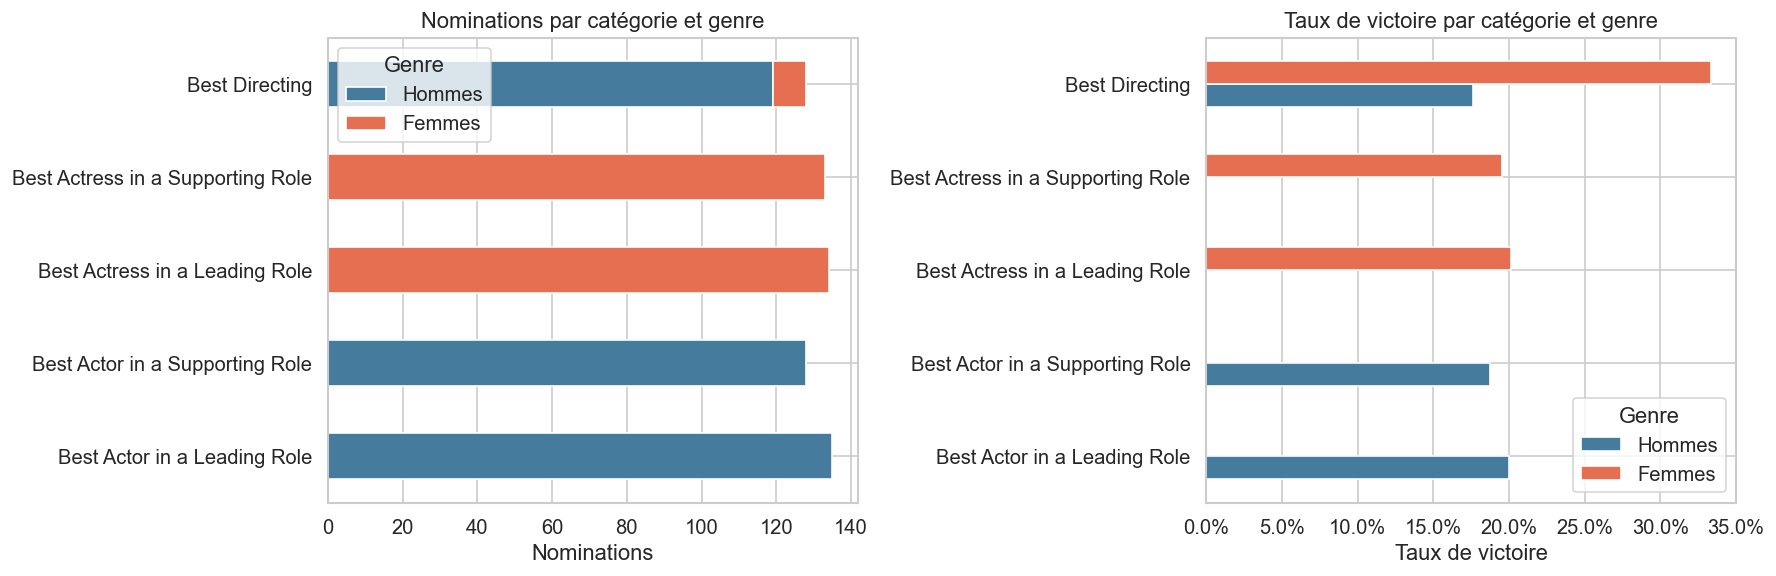


Focus Best Directing :
      category gender  noms  wins  win_rate
Best Directing      F     9     3  0.333333
Best Directing      M   119    21  0.176471

→ Sur 2000–2025, 9 femmes nominées sur 128 nominations totales (7.0 %).


In [16]:
cat_gender = (df_gender_p.groupby(['category', 'gender'])
                          .agg(noms=('winner', 'count'), wins=('winner', 'sum'))
                          .reset_index())
cat_gender['win_rate'] = cat_gender['wins'] / cat_gender['noms']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Nominations empilées par catégorie
pivot_noms = cat_gender.pivot(index='category', columns='gender', values='noms').fillna(0)
pivot_noms = pivot_noms.reindex(columns=['M', 'F'])
pivot_noms.plot(kind='barh', stacked=True, ax=axes[0],
                color=['#457B9D', '#E76F51'], edgecolor='white')
axes[0].set_title('Nominations par catégorie et genre')
axes[0].set_xlabel('Nominations')
axes[0].set_ylabel('')
axes[0].legend(['Hommes', 'Femmes'], title='Genre')

# Taux de victoire par catégorie et genre
pivot_wr = cat_gender.pivot(index='category', columns='gender', values='win_rate').fillna(0)
pivot_wr = pivot_wr.reindex(columns=['M', 'F'])
pivot_wr.plot(kind='barh', ax=axes[1], color=['#457B9D', '#E76F51'], edgecolor='white')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_title('Taux de victoire par catégorie et genre')
axes[1].set_xlabel('Taux de victoire')
axes[1].set_ylabel('')
axes[1].legend(['Hommes', 'Femmes'], title='Genre')

plt.tight_layout()
plt.show()

print('\nFocus Best Directing :')
bd_gender = cat_gender[cat_gender.category == 'Best Directing']
print(bd_gender.to_string(index=False))
print(f'\n→ Sur 2000–2025, {int(bd_gender[bd_gender.gender=="F"]["noms"].sum())} femmes nominées sur '
      f'{int(bd_gender["noms"].sum())} nominations totales '
      f'({bd_gender[bd_gender.gender=="F"]["noms"].sum()/bd_gender["noms"].sum()*100:.1f} %).')

### 11.3 Évolution temporelle — femmes réalisatrices nominées par décennie

Le déséquilibre est-il en train de se résorber ? On regroupe par tranche de 5 ans pour lisser le bruit.

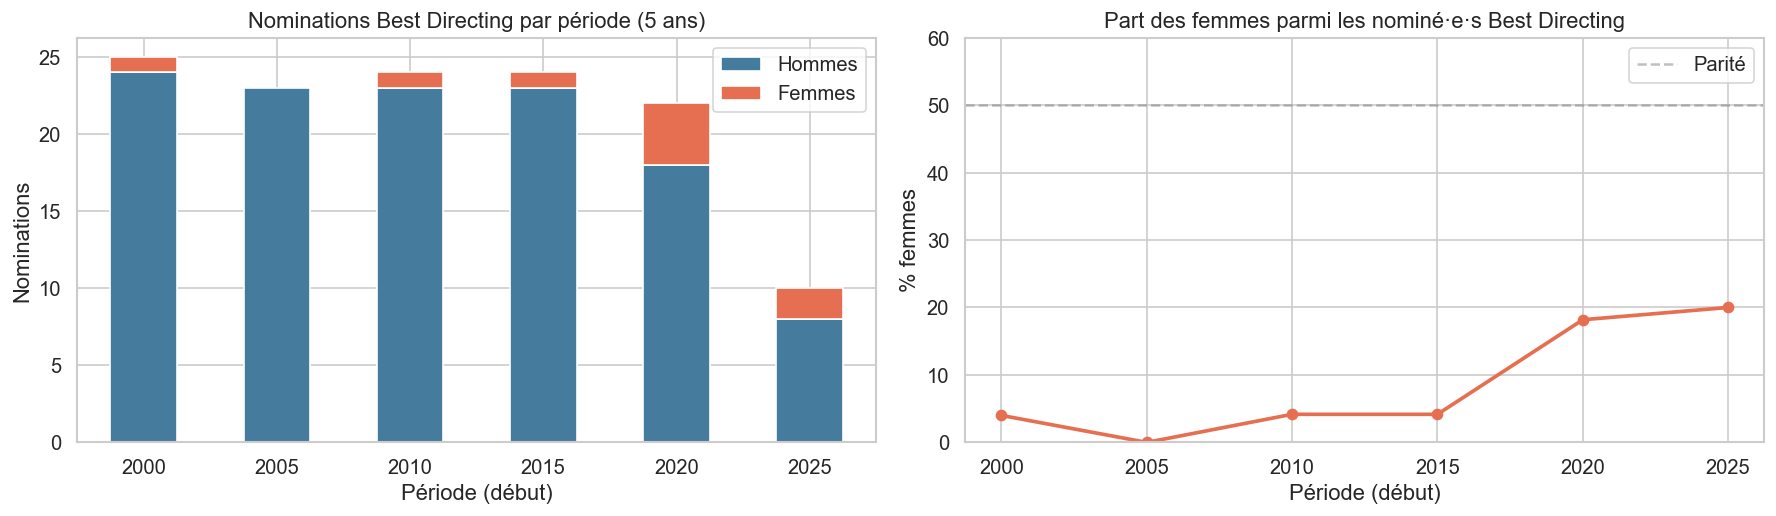

gender   M  F  share_F
period                
2000    24  1    0.040
2005    23  0    0.000
2010    23  1    0.042
2015    23  1    0.042
2020    18  4    0.182
2025     8  2    0.200


In [17]:
bd = df_gender_p[df_gender_p.category == 'Best Directing'].copy()
bd['period'] = (bd['year'] // 5 * 5).astype(int)

evo = (bd.groupby(['period', 'gender'])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=['M', 'F'], fill_value=0))
evo['share_F'] = evo['F'] / (evo['M'] + evo['F'])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

evo[['M', 'F']].plot(kind='bar', stacked=True, ax=axes[0],
                     color=['#457B9D', '#E76F51'], edgecolor='white')
axes[0].set_title('Nominations Best Directing par période (5 ans)')
axes[0].set_xlabel('Période (début)')
axes[0].set_ylabel('Nominations')
axes[0].legend(['Hommes', 'Femmes'])
axes[0].tick_params(axis='x', rotation=0)

axes[1].plot(evo.index.astype(str), evo['share_F'] * 100, marker='o', lw=2.2, color='#E76F51')
axes[1].set_title('Part des femmes parmi les nominé·e·s Best Directing')
axes[1].set_xlabel('Période (début)')
axes[1].set_ylabel('% femmes')
axes[1].axhline(50, ls='--', color='gray', alpha=0.5, label='Parité')
axes[1].legend()
axes[1].set_ylim(0, 60)

plt.tight_layout()
plt.show()

print(evo.round(3))

### 11.4 Effets potentiels sur les modèles ML

**Synthèse pour le notebook de modélisation** :

| Catégorie | Genre encodé | Risque de biais sur le modèle |
|---|---|---|
| Best Actor/Actress (Lead & Supporting) | Oui, par construction (Académie) | **Aucun** : les 4 catégories sont modélisées séparément. Le genre ne fuit pas dans les features. |
| Best Directing | Inféré (8 F / 90 réalisateurs unique·s) | **Faible** : ~7 % des nominations sont féminines. `n_prior_noms` et `n_prior_wins` capturent peu de signal pour les femmes (historique limité). Le modèle apprendra surtout un *prior masculin* — interpréter `is_overdue` avec prudence. |
| Best Picture, Animation, VFX, Screenplay | Non (unité = film) | **Non applicable** : pas de variable de genre à l'échelle film. À étendre via `directors` + `name.basics` si on souhaite un signal "film réalisé par une femme". |

**Hypothèses pour l'EDA finale** :
1. Les modèles d'acting ne sont pas biaisés par le déséquilibre de genre — le déséquilibre est *entre* catégories, pas *dans* une catégorie.
2. Pour Best Directing, l'historique `n_prior_noms` favorise mécaniquement les vétérans (donc les hommes, sur-représentés depuis 30 ans) ; un modèle qui pondère fortement cette feature aura un biais conservateur — c'est un *finding* à signaler, pas un bug.
3. Piste d'amélioration : enrichir le dataset avec le genre du *réalisateur principal du film* (via `directors` IMDb + `name.basics`), pour créer une feature `director_is_female` utilisable dans toutes les catégories film. Non implémenté ici pour rester DRY avec le notebook de modélisation actuel.

## 12. Synthèse & Hypothèses pour la Modélisation

### Observations clés

| Variable | Observation | Signal prédictif |
|----------|-------------|------------------|
| `imdb_rating` | Les gagnants ont une note légèrement supérieure (~+0.1–0.2 pts) | Faible mais présent |
| `imdb_votes` | Les gagnants sont légèrement plus populaires (log-votes) | Faible |
| `runtime_minutes` | Les gagnants ont tendance à être plus longs | Modéré |
| `genre` | Drama, Biography, History dominent chez les gagnants | Fort |
| `category` | Le taux de victoire théorique est ~20% (5 nommés/catégorie) | Dépend du contexte |

### Implications pour la modélisation

1. **Feature engineering** : créer `is_drama`, `is_biography`, encoder les genres en one-hot
2. **Analyse par catégorie** : construire des modèles séparés par catégorie (Best Picture vs autres)
3. **Variables manquantes** : imputer ou exclure `n_cast`, `writers`
4. **Données externes** : enrichir avec box-office, scores critiques (Rotten Tomatoes, Metacritic)
5. **Baseline model** : régression logistique par catégorie avec les features actuelles

> **Suite du pipeline** : ces hypothèses sont formalisées et chiffrées dans [`03_EDA_justification.ipynb`](03_EDA_justification.ipynb), puis traduites en modèles dans [`05_Nomination_modeling.ipynb`](05_Nomination_modeling.ipynb) (nominations) et [`06_Winner_modeling.ipynb`](06_Winner_modeling.ipynb) (gagnant).